# Task 04 - Applications & Shortlisting (Explainability)

## AI/ML Engineer - Phase 2

### Objective

Develop an AI-powered Job Matching System that matches students with suitable jobs using Machine Learning while providing explainable recommendations.

---

### Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Flask
- Joblib
- Matplotlib

In [41]:
import pandas as pd
import numpy as np
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier

## Load Dataset

In [42]:
students = pd.read_csv("data/students.csv")
jobs = pd.read_csv("data/jobs.csv")

students.head()

,student_id,name,skills,experience,education
0,1,Student_1,"HTML, YOLO, OpenCV, NumPy, Flask, React, Linux",0,B.Tech
1,2,Student_2,"Flask, Java, FastAPI, Statistics",5,M.Sc
2,3,Student_3,"YOLO, CSS, Git, React",2,B.Tech
3,4,Student_4,"Spring Boot, JavaScript, Excel, Scikit-learn",5,B.Sc
4,5,Student_5,"TensorFlow, Docker, FastAPI, Git",0,B.Sc


In [43]:
jobs.head()

,job_id,job_title,required_skills,min_experience
0,101,Data Scientist,"Python, Statistics, Pandas, NumPy, SQL, OpenCV",1
1,102,Python Developer,"Python, FastAPI, Docker, Git, Pandas, Flask",5
2,103,Software Engineer,"Java, Git, Linux, MySQL, Machine Learning, Spr...",3
3,104,AI ML Engineer,"Python, Machine Learning, Flask, Scikit-learn,...",1
4,105,Python Developer,"Python, FastAPI, Docker, Git, Java, Power BI",0


## Dataset Information

In [44]:
students.info()
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   student_id  100 non-null    int64 
 1   name        100 non-null    object
 2   skills      100 non-null    object
 3   experience  100 non-null    int64 
 4   education   100 non-null    object
dtypes: int64(2), object(3)
memory usage: 4.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_id           30 non-null     int64 
 1   job_title        30 non-null     object
 2   required_skills  30 non-null     object
 3   min_experience   30 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 1.1+ KB


In [45]:
students.describe(include="all")

,student_id,name,skills,experience,education
count,100.000000,100,100,100.000000,100
unique,NaN,100,100,NaN,4
top,NaN,Student_1,"HTML, YOLO, OpenCV, NumPy, Flask, React, Linux",NaN,B.Tech
freq,NaN,1,1,NaN,29
mean,50.500000,NaN,NaN,2.330000,NaN
std,29.011492,NaN,NaN,1.837076,NaN
min,1.000000,NaN,NaN,0.000000,NaN
25%,25.750000,NaN,NaN,1.000000,NaN
50%,50.500000,NaN,NaN,2.000000,NaN
75%,75.250000,NaN,NaN,4.000000,NaN


## TF-IDF Vectorization

In [46]:
vectorizer = TfidfVectorizer()

all_text = pd.concat(
    [students["skills"], jobs["required_skills"]],
    ignore_index=True
)

vectorizer.fit(all_text)

student_vectors = vectorizer.transform(students["skills"])
job_vectors = vectorizer.transform(jobs["required_skills"])

print(student_vectors.shape)
print(job_vectors.shape)

(100, 30)
(30, 30)


## Student Job Matching

In [47]:
similarity = cosine_similarity(
    student_vectors,
    job_vectors
)

similarity[:5]

array([[0.30587093, 0.1580297 , 0.14904449, 0.13670158, 0.        ,
        0.1697947 , 0.30881342, 0.16711694, 0.28485834, 0.34468342,
        0.44464595, 0.14992911, 0.1354307 , 0.31821716, 0.        ,
        0.12350164, 0.47125498, 0.2907235 , 0.11407728, 0.        ,
        0.11408869, 0.29970564, 0.28603292, 0.3022417 , 0.26737584,
        0.27321331, 0.        , 0.14968939, 0.13791098, 0.15833542],
       [0.20947346, 0.45303461, 0.16220185, 0.39189182, 0.37430569,
        0.18478384, 0.19021967, 0.19452651, 0.        , 0.44262226,
        0.        , 0.17451963, 0.18297518, 0.39622426, 0.18902118,
        0.20546162, 0.18585058, 0.        , 0.        , 0.45558463,
        0.18980192, 0.42071705, 0.        , 0.40439354, 0.16469461,
        0.        , 0.19399336, 0.        , 0.34976631, 0.17231296],
       [0.        , 0.15862598, 0.13738256, 0.        , 0.13911255,
        0.15650918, 0.16111324, 0.        , 0.4176407 , 0.40630558,
        0.40838759, 0.        , 0.        , 0.

## Model Training

In [48]:
from train import model

model

RandomForestClassifier(random_state=42)

## Evaluation Metrics

In [49]:
with open("outputs/metrics.txt") as file:
    print(file.read())

Model Evaluation Metrics

Accuracy            : 0.9667
Precision           : 1.0000
Recall              : 0.9000
False Positive Rate : 0.0000



## Prediction Results

In [50]:
predictions = pd.read_csv("outputs/predictions.csv")

predictions.head(10)

,student_id,student_name,job_id,job_title,match_score,explanation
0,1,Student_1,117,Computer Vision Engineer,47.13,Student_1 matches the role 'Computer Vision En...
1,2,Student_2,120,Python Developer,45.56,Student_2 matches the role 'Python Developer' ...
2,3,Student_3,118,Frontend Developer,57.21,Student_3 matches the role 'Frontend Developer...
3,4,Student_4,129,Backend Developer,57.46,Student_4 matches the role 'Backend Developer'...
4,5,Student_5,102,Python Developer,58.02,Student_5 matches the role 'Python Developer' ...
5,6,Student_6,111,Frontend Developer,60.62,Student_6 matches the role 'Frontend Developer...
6,7,Student_7,123,Frontend Developer,64.71,Student_7 matches the role 'Frontend Developer...
7,8,Student_8,112,AI Research Intern,68.32,Student_8 matches the role 'AI Research Intern...
8,9,Student_9,119,Data Analyst,50.51,Student_9 matches the role 'Data Analyst' beca...
9,10,Student_10,129,Backend Developer,51.88,Student_10 matches the role 'Backend Developer...


## Confusion Matrix

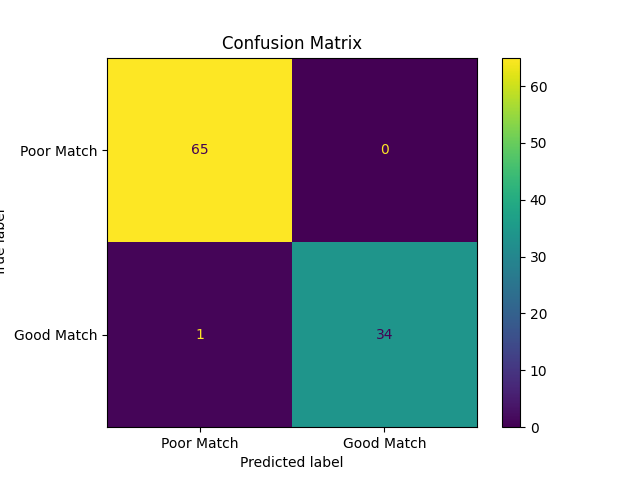

In [51]:
from IPython.display import Image

Image("outputs/confusion_matrix.png")

## Precision Recall Curve

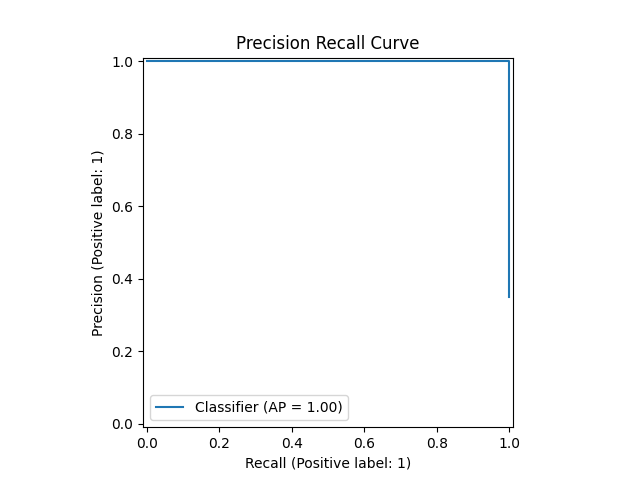

In [52]:
Image("outputs/precision_recall_curve.png")

## Explainability Example

In [53]:
import json

with open("outputs/explanation_examples.json") as file:
    explanations = json.load(file)

explanations[0]

{'student_id': 1,
 'student_name': 'Student_1',
 'job_id': 117,
 'job_title': 'Computer Vision Engineer',
 'match_score': 47.13,
 'explanation': "Student_1 matched because the student has skills similar to 'Python, OpenCV, YOLO, Deep Learning, Flask, TensorFlow'."}

# Conclusion

Successfully developed an AI-powered Job Matching and Explainability System.

### Features Implemented

- Student-Job Matching
- TF-IDF Similarity
- Explainability
- Match Score
- Random Forest Classification
- Evaluation Metrics
- Confusion Matrix
- Precision Recall Curve
- Model Serialization
- Flask API